# Comparing LFC of genes
We create heatmaps for the binned aligned pseudotimes made with cellalign. With those we can see if gene expressions are comparable over time in cells and nuclei

In [ ]:
%run ../Script/analysisLibraries

In [ ]:
%run ../Script/pythonScripts.py

In [ ]:
%matplotlib inline

In [ ]:
%load_ext rpy2.ipython

In [ ]:
adata = sc.read('./write/adata.rf_correction.h5ad')

In [ ]:
import re
geneMask = [ re.match("^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|MTR",i)!=None for i in adata.var_names]

In [ ]:
adata.var_names[geneMask]

Index(['CCNA1', 'CCNB3', 'CCND3', 'HIST1H1A', 'HIST1H1C', 'HIST1H1D',
       'HIST1H2AA', 'HIST1H2BA', 'MRPS27'],
      dtype='object')

In [ ]:
adata = adata[:, np.invert(geneMask)].copy()

In [ ]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

## Uniforming clustering with nuclei as a reference for cells

## Subsampling

Getting as many nuclei as cells

In [ ]:
CELLS

AnnData object with n_obs × n_vars = 2676 × 4991
    obs: 'spl_prop', 'uns_prop', 'perc_rp', 'perc_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'perc_PRM1', 'perc_PRM2', 'perc_LOC104001214', 'perc_KEF41-p07', 'perc_KEF41-p04', 'perc_MTRNR2L14', 'genes_threshold_filter', 'all_filters', 'correction_quantity', 'leiden', 'doublet_score', 'bw_adaptive from LE with bw_adaptive_leiden', 'bw_adaptive from DM with bw_adaptive_leiden', 'topo_leiden_LE', 'topo_leiden_DM', 'SpermatogoniaA_score', 'SpermatogoniaB_score', 'Round.Spt_score', 'Elong.Spt_score', 'Sertoli_score', 'Macroph_score', 'Endothelial_score', 'Myoid_score', 'Smooth_Muscle_score', 'Leptotene_score', 'Zygotene_score', 'Pachytene_score', 'Diplotene_score', 'clusters_single', 'perc_TNP1', 'perc_HSP90AA1', 'batch', 'clusters_compact', 'topo_leiden_LE_merge', 'topo_l

In [ ]:
CELLS.X = CELLS.layers['soupx_counts'].copy()
NUCLEI.X = NUCLEI.layers['soupx_counts'].copy()

In [ ]:
sc.pp.calculate_qc_metrics(CELLS, inplace=True)

In [ ]:
sc.pp.calculate_qc_metrics(NUCLEI, inplace=True)

In [ ]:
del NUCLEI.uns['log1p'], CELLS.uns['log1p']

In [ ]:
sc.pp.normalize_total(NUCLEI)
sc.pp.normalize_total(CELLS)
sc.pp.log1p(NUCLEI)
sc.pp.log1p(CELLS)
sc.pp.highly_variable_genes(NUCLEI, n_top_genes=10000)
sc.pp.highly_variable_genes(CELLS, n_top_genes=10000)

In [ ]:
sc.pp.subsample(NUCLEI, n_obs=CELLS.shape[0], random_state=123)

subsampling counts in each cell

In [ ]:
NUCLEI_S = NUCLEI.copy() #sc.pp.downsample_counts(NUCLEI, counts_per_cell=int(np.mean(CELLS.obs['total_counts'])), copy=True, random_state=123)
CELLS_S = sc.pp.downsample_counts(CELLS, counts_per_cell=int(np.mean(NUCLEI.obs['total_counts'])), copy=True, random_state=123)

## Comparison on whole dataset

selecting only variable genes

In [ ]:
NUCLEI_S = NUCLEI_S[:, NUCLEI.var['highly_variable']|CELLS.var['highly_variable']].copy()

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [ ]:
CELLS_S = CELLS_S[:, NUCLEI.var['highly_variable']|CELLS.var['highly_variable']].copy()

In [ ]:
Sdata = ad.AnnData.concatenate(NUCLEI_S, CELLS_S, batch_key='Dataset', batch_categories=['Nuclei', 'Cells'])

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/merge.py:217: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(dtype):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/merge.py:217: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(dtype):


Change the names of some transcripts to the related genes, so it is easier to understand

In [ ]:
#names = pd.Series(Sdata.var_names, index=Sdata.var_names)
#names[['KEF41-p01','KEF41-p02','KEF41-p03','KEF41-p04','KEF41-p05','KEF41-p06',
#       'KEF41-p07','KEF41-p08','KEF41-p09','KEF41-p10','KEF41-p11','KEF41-p12',
#       'KEF41-p13']] = ['CYTB','ND6','ND5','ND4','ND4L','ND3','COX3','ATP6','ATP8','COX2','COX1','ND2','ND1']

In [ ]:
#Sdata.var_names = np.array(names)

In [ ]:
Sdata.obs

,spl_prop,uns_prop,perc_rp,perc_mito,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,perc_TNP1,perc_HSP90AA1,batch,clusters_compact,topo_leiden_LE_merge,topo_leiden_DM_merge,Eigenvector_5,dpt_palantir,dpt_palantir_cellalign,Dataset
ACATCCCTCAGACATC-Nuclei-Nuclei,0.281508,0.718492,0.010781,0.010592,638,6.459904,1368.0,7.221836,33.114035,46.345029,...,NaN,NaN,Nuclei,SpermatogoniaB,10,11,0.005076,0.080178,0.082044,Nuclei
GACCCTTTCGCTACAA-Nuclei-Nuclei,0.534149,0.465851,0.010036,0.008820,507,6.230481,985.0,6.893656,39.898477,51.878173,...,NaN,NaN,Nuclei,Elong.Spt,1,2,0.005860,0.944409,0.938897,Nuclei
CACCAAAGTCATCCGG-Nuclei-Nuclei,0.417578,0.582422,0.012235,0.009356,495,6.206576,844.0,6.739337,34.360190,46.919431,...,NaN,NaN,Nuclei,Round.Spt,2,5,-0.006667,0.741962,0.734690,Nuclei
CCAATTTAGAGGTTTA-Nuclei-Nuclei,0.236264,0.763736,0.010055,0.012289,445,6.100319,1753.0,7.469654,48.374216,66.457501,...,NaN,NaN,Nuclei,Spermatocites,5,4,0.015126,0.375835,0.367451,Nuclei
ATTACTCTCTGGGATT-Nuclei-Nuclei,0.332186,0.667814,0.009893,0.010414,638,6.459904,1275.0,7.151485,30.431373,43.843137,...,NaN,NaN,Nuclei,Round.Spt,2,5,-0.010900,0.764834,0.755192,Nuclei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCAGCGGTCT-Cells-Cells,0.408861,0.591139,0.008378,0.010828,893,6.795706,2246.0,7.717351,26.090828,39.136242,...,0.000000,0.000143,Cells,Round.Spt,2,5,-0.015542,0.749503,0.755097,Cells
TTTGTTGGTACAGTCT-Cells-Cells,0.549630,0.450370,0.009534,0.008331,1228,7.113956,2896.0,7.971431,21.961326,32.009669,...,0.008751,0.000000,Cells,Round.Spt,0,0,0.001205,0.857129,0.857129,Cells
TTTGTTGGTCTACGTA-Cells-Cells,0.533394,0.466606,0.017171,0.013123,591,6.383507,2434.0,7.797702,41.824158,58.792112,...,0.000000,0.001729,Cells,Spermatocites,5,4,-0.008319,0.556596,0.551342,Cells
TTTGTTGTCCATTTAC-Cells-Cells,0.497133,0.502867,0.011296,0.021899,362,5.894403,838.0,6.732211,49.761337,63.842482,...,0.000000,0.004952,Cells,Spermatocites,6,16,0.007709,0.290586,0.285761,Cells


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

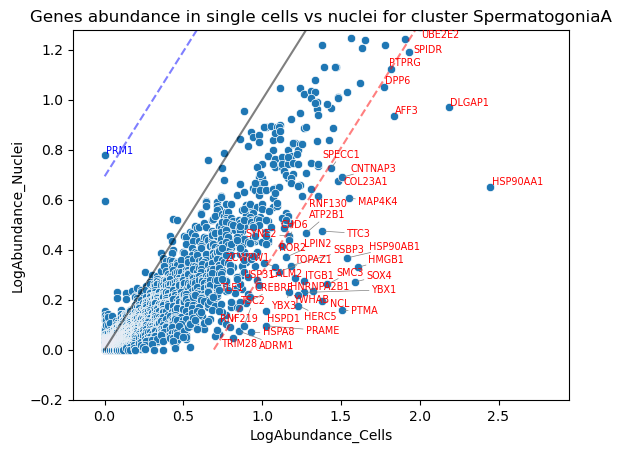

Nuclei-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
0,PRM1,0.778361,0.000000,2.177901


Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4832,PTPRG,1.120829,1.816092,2.004236
4914,ROR2,0.416139,1.126437,2.034598
4922,SPECC1,0.724448,1.436782,2.038743
4939,SYNE2,0.453277,1.172414,2.052661
4940,DPP6,1.050573,1.770115,2.053492
4946,SPIDR,1.192148,1.931034,2.093603
4947,COL23A1,0.674023,1.482759,2.245067
4950,UBE2E2,1.290244,2.000000,2.033494
4951,CREBRF,0.185866,0.896552,2.035386
4952,LPIN2,0.369247,1.149425,2.181862


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

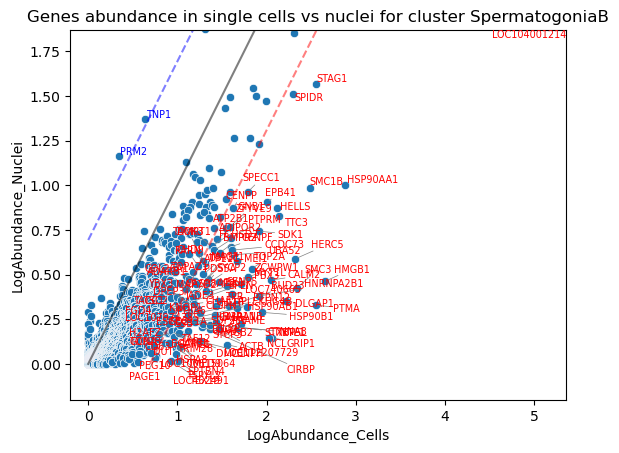

Nuclei-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
2,PRM2,1.161673,0.349059,2.253791
3,TNP1,1.368908,0.642296,2.068063


Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4758,YBX3,0.351214,1.099907,2.114234
4771,COL26A1,0.469790,1.174681,2.023626
4796,DMRT1,0.661202,1.374484,2.040676
4803,CENPP,0.870876,1.626309,2.128532
4819,FGD4,0.209108,0.910918,2.017402
4832,TAOK3,0.562879,1.306371,2.103267
4847,CHD9,0.577646,1.283278,2.025126
4856,TOPAZ1,0.466362,1.193268,2.068669
4865,LOC107974385,0.254420,0.971036,2.047494
4873,PBX3,0.349934,1.174082,2.279937


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

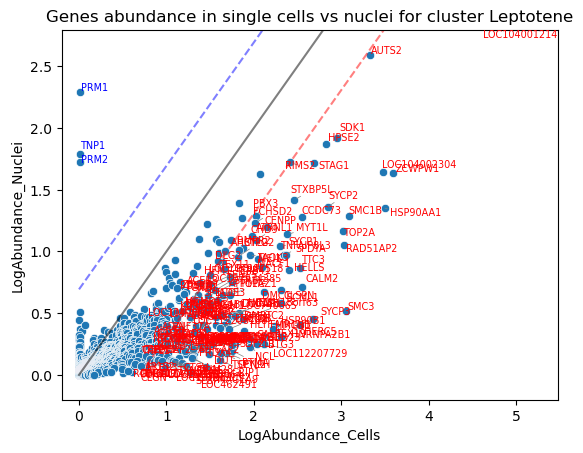

Nuclei-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
0,PRM1,2.294636,0.014647,9.776572
1,TNP1,1.792587,0.010621,5.941527
2,PRM2,1.727063,0.011242,5.561241


Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4674,DLG2,0.916206,1.633403,2.048684
4761,RIMS2,1.721225,2.414155,1.999565
4766,PBX3,1.290676,2.027129,2.088515
4768,AHCYL2,1.024294,1.876725,2.345343
4775,KLRG1,0.541728,1.277436,2.086960
4782,ACER3,0.647152,1.356971,2.033624
4789,ZFYVE9,0.603851,1.303210,2.012462
4790,STPG2,0.954716,1.815496,2.365004
4791,C5H5orf58,0.467585,1.273760,2.239327
4792,SYCP1,1.041151,2.302950,3.531770


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

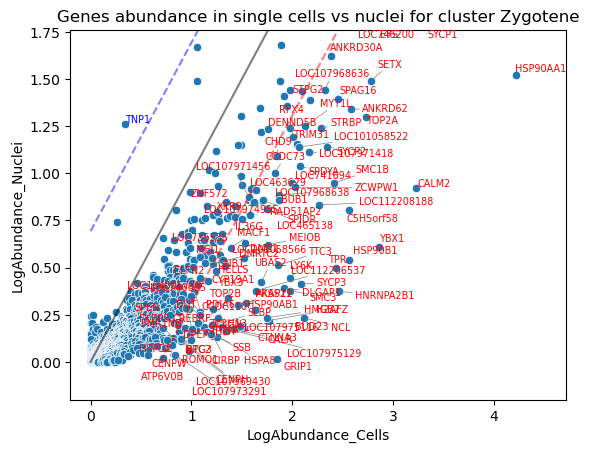

Nuclei-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
0,TNP1,1.259662,0.344847,2.496314


Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4661,ZNF572,0.860213,1.572012,2.037652
4722,RAD51AP2,0.855907,1.705223,2.338048
4735,CYP19A1,0.426932,1.159337,2.080078
4774,LOC107974955,0.844408,1.613161,2.157075
4799,RFX4,1.190688,2.002426,2.251820
4802,LOC463629,0.912019,1.642195,2.075446
4812,LOC107971456,0.874077,1.567346,2.000244
4830,LOC101058566,0.520038,1.213692,2.001014
4854,LOC735535,0.565654,1.278602,2.039994
4856,TRIM31,1.156068,2.046776,2.436855


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

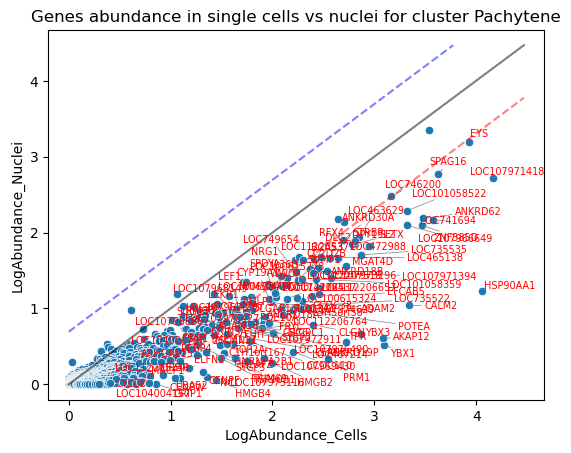

Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4794,LOC107976427,0.844376,1.656362,2.252378
4797,SUMF1,1.538925,2.443209,2.470163
4810,GULP1,0.985927,1.797311,2.251019
4816,SUGCT,0.762647,1.480122,2.049251
4819,ARHGAP15,0.423938,1.116040,1.997910
4823,LOC735522,1.013570,2.091817,2.939524
4827,LOC107976490,0.777709,1.474808,2.007920
4828,ZNF385D,2.097114,3.463692,3.921906
4833,WWOX,1.399197,2.137831,2.093074
4857,GRIP1,0.003408,0.857279,2.348722


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

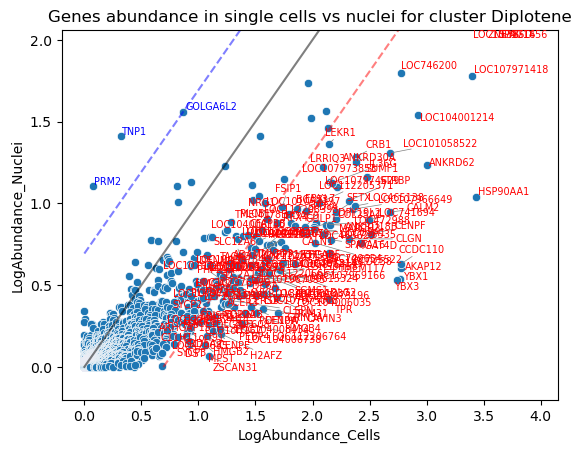

Nuclei-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
0,TNP1,1.409950,0.318937,2.977289
1,PRM2,1.105639,0.071636,2.812300
6,GOLGA6L2,1.560239,0.865630,2.002926


Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4723,PLCB1,0.801738,1.501470,2.013213
4746,NRG1,0.902565,1.599242,2.007071
4760,TAOK3,0.615464,1.344498,2.073079
4788,PLXDC2,0.474324,1.209447,2.085737
4794,TMEM178B,0.838965,1.556245,2.048853
4799,DENND5B,0.662435,1.378865,2.047112
4802,SLC2A13,0.512196,1.327778,2.260492
4804,HPSE2,0.752827,1.650689,2.454350
4805,BCAS3,0.962785,1.861540,2.456544
4806,HDAC9,0.877360,1.809950,2.541081


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

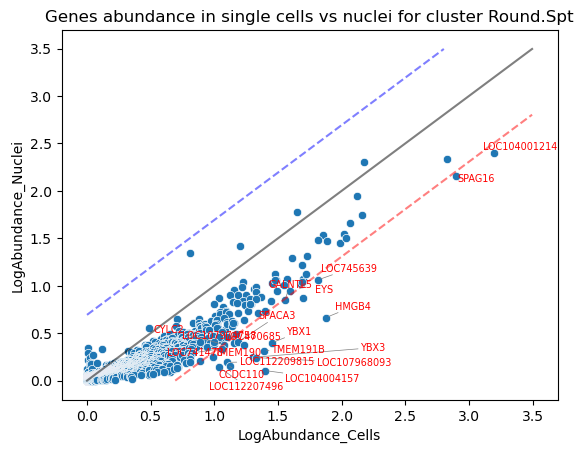

Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4929,LOC745639,1.062322,1.815564,2.123876
4930,SPAG16,2.158201,2.901482,2.102824
4965,EYS,0.871873,1.699178,2.287145
4972,CYLC2,0.380183,1.074659,2.002659
4974,LOC104001214,2.400058,3.196337,2.217276
4975,LOC741478,0.337621,1.057162,2.053491
4976,GALNTL5,0.853528,1.554767,2.016248
4977,LOC112207496,0.138635,1.039249,2.461114
4979,LOC107974758,0.397364,1.156593,2.136628
4980,SPACA3,0.410753,1.188641,2.176869


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

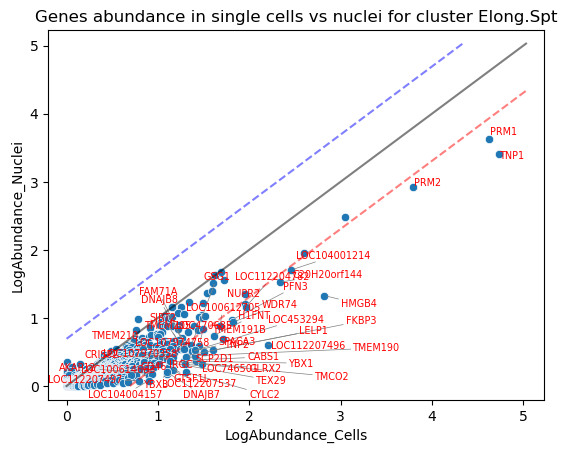

Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4867,PRM1,3.621336,4.622259,2.720791
4890,LOC104001214,1.702887,2.456162,2.123945
4891,PRM2,2.923645,3.787237,2.371665
4895,FAM71A,0.576581,1.309279,2.080686
4916,CRISP2,0.400943,1.124568,2.061895
4930,NUPR2,1.202255,1.947558,2.107079
4932,DNAJB8,0.601397,1.296022,2.002958
4939,TMEM210,0.436943,1.128559,1.996940
4941,LOC100614663,0.141406,0.897900,2.130791
4942,LOC107974758,0.541889,1.237873,2.005682


In [ ]:
from adjustText import adjust_text

for CLUSTER in ['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene',  'Zygotene' ,  
    'Pachytene', 'Diplotene', 'Round.Spt', 'Elong.Spt']:
    
    from IPython.display import display
    
    Sdata_2 = Sdata[Sdata.obs['clusters_single']==CLUSTER].copy()
    sc.tl.rank_genes_groups(Sdata_2, groupby='Dataset',  reference='Cells')
    result = Sdata_2.uns['rank_genes_groups']
    Sdata.uns[f'rank_genes_groups_{CLUSTER}'] = Sdata_2.uns['rank_genes_groups'].copy()
    groups = result['names'].dtype.names
    X = pd.DataFrame(
     {group + '_' + key[:1].upper(): result[key][group]
     for group in groups for key in ['names', 'pvals_adj','logfoldchanges']})

    Ndata = Sdata_2[ Sdata_2.obs['Dataset']=='Nuclei' ].copy()
    nuclei_ab = np.ravel(np.mean(Ndata[:, X['Nuclei_N']].X, 0 ))

    Cdata = Sdata_2[ Sdata_2.obs['Dataset']=='Cells' ].copy()
    cells_ab = np.ravel( np.mean(Cdata[:, X['Nuclei_N']].X, 0) )
    
    X['LogAbundance_Cells'] = cells_ab
    X['LogAbundance_Nuclei'] = nuclei_ab
    X['Abundance_Cells'] = np.exp(cells_ab)
    X['Abundance_Nuclei'] = np.exp(nuclei_ab)
        
    fig, ax = plt.subplots(1,1)
    f = sns.scatterplot(data=X,
          x='LogAbundance_Cells',
          y='LogAbundance_Nuclei',
          ax=ax)

    Xsub_N = X.query('LogAbundance_Nuclei-LogAbundance_Cells>0.69 & Nuclei_P<.0001')
    Xsub_C = X.query('LogAbundance_Cells-LogAbundance_Nuclei>0.69 & Nuclei_P<.0001')
    
    if( (Xsub_N.shape[0]>0) & (Xsub_C.shape[0]>0) ):
     xmax = np.max( Xsub_C.LogAbundance_Cells )
     ymax = np.max( Xsub_N.LogAbundance_Nuclei )
     max_all = np.max([xmax,ymax])+.3
    elif( (Xsub_N.shape[0]>0) & (Xsub_C.shape[0]==0) ):
     ymax = np.max( Xsub_N.LogAbundance_Nuclei )
     xmax=ymax
     max_all = np.max([xmax,ymax])+.3
    elif( (Xsub_N.shape[0]==0) & (Xsub_C.shape[0]>0) ):
     xmax = np.max( Xsub_C.LogAbundance_Cells )
     ymax=xmax
     max_all = np.max([xmax,ymax])+.3
    else:
     xmax = ax.get_xlim()[1]
     ymax = ax.get_ylim()[1]
     max_all = np.max([xmax,ymax])    

    ax.set_xlim(-.2, xmax+.5)
    ax.set_ylim(-.2, ymax+.5)
    
    ax.plot([0,max_all],[0,max_all], color='black', alpha=.5)
    ax.plot([np.log(2),max_all],[0,max_all-np.log(2)], linestyle='dashed', color='red', alpha=.5)
    ax.plot([0,max_all-np.log(2)],[np.log(2),max_all], linestyle='dashed', color='blue',alpha=.5)

    texts = []
    
    Xsub = X.query('LogAbundance_Nuclei-LogAbundance_Cells>0.69')
    for IDX in Xsub.index:
     x_coord = Xsub.loc[IDX,'LogAbundance_Cells']
     y_coord = Xsub.loc[IDX,'LogAbundance_Nuclei']
     text = Xsub.loc[IDX,'Nuclei_N']
     texts.append(ax.text(x_coord, y_coord, text, fontsize='x-small', color='blue'))

    Xsub = X.query('LogAbundance_Cells-LogAbundance_Nuclei>0.69')
    for IDX in Xsub.index:
     x_coord = Xsub.loc[IDX,'LogAbundance_Cells']
     y_coord = Xsub.loc[IDX,'LogAbundance_Nuclei']
     text = Xsub.loc[IDX,'Nuclei_N']
     texts.append(ax.text(x_coord, y_coord, text, fontsize='x-small', color='red'))
    
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    title=ax.set_title(f'Genes abundance in single cells vs nuclei for cluster {CLUSTER}')

    plt.savefig(f'./{CLUSTER}_LFC.png', bbox_inches='tight', transparent=True )
    plt.show()

    if((Xsub_N.shape[0]>0)):
     print("Nuclei-abundant genes:")
     Xsub_N = Xsub_N[ ['Nuclei_N', 'LogAbundance_Nuclei', 'LogAbundance_Cells'] ]
     Xsub_N.columns = ['Gene', 'LogMeanNuclei', 'LogMeanCells']
     Xsub_N['FC'] = np.exp(Xsub_N.LogMeanNuclei - Xsub_N.LogMeanCells)
     display( Xsub_N.style )
     Xsub_N.to_csv(f'{CLUSTER}_LFC_Nuclei.csv', index_label=False)
    if((Xsub_C.shape[0]>0)):
     print("Cells-abundant genes:")
     Xsub_C = Xsub_C[ ['Nuclei_N', 'LogAbundance_Nuclei', 'LogAbundance_Cells'] ]
     Xsub_C.columns = ['Gene', 'LogMeanNuclei', 'LogMeanCells']
     Xsub_C['FC'] = np.exp(Xsub_C.LogMeanCells - Xsub_C.LogMeanNuclei)
     display( Xsub_C.style )
     Xsub_C.to_csv(f'{CLUSTER}_LFC_Cells.csv', index_label=False)

In [ ]:
Sdata.write('./write/LFC_comparison.h5ad')

## GSEA analysis

In [ ]:
Sdata = sc.read('./write/LFC_comparison.h5ad')

In [ ]:
# Get all cluster names from the rank_genes_groups keys in Sdata.uns
cluster_names = ['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 
                 'Pachytene', 'Diplotene', 'Round.Spt', 'Elong.Spt']

# Create a list to store dataframes for each cluster
dfs_list = []

for cluster in cluster_names:
    # Get the rank_genes_groups result for this cluster
    result = Sdata.uns[f'rank_genes_groups_{cluster}']
    groups = result['names'].dtype.names
    
    # Create dataframe with all the information
    df = pd.DataFrame({
        group + '_' + key[:1].upper(): result[key][group]
        for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges']
    })
    
    # Add cluster column
    df['Cluster'] = cluster
    
    # Append to list
    dfs_list.append(df)

# Concatenate all dataframes
all_clusters_df = pd.concat(dfs_list, ignore_index=True)

# Display the result
all_clusters_df

,Nuclei_N,Nuclei_P,Nuclei_L,Cluster
0,PRM1,2.432783e-21,30.133570,SpermatogoniaA
1,TNP1,1.537657e-17,29.602413,SpermatogoniaA
2,LOC112204782,1.425771e-10,27.311172,SpermatogoniaA
3,TPPP2,3.689309e-09,27.118143,SpermatogoniaA
4,GSG1,3.729593e-08,26.881132,SpermatogoniaA
...,...,...,...,...
39923,FKBP3,1.035320e-90,-2.526633,Elong.Spt
39924,TMEM191B,1.032183e-97,-2.198873,Elong.Spt
39925,TMCO2,8.949374e-104,-3.189162,Elong.Spt
39926,HMGB4,6.171511e-152,-2.508534,Elong.Spt


In [35]:
all_clusters_df.to_csv('./tables_LFC_comparison_all_clusters.csv', index=False)

ERROR: Error in all_clusters_df.to_csv("./tables_LFC_comparison_all_clusters.csv", : could not find function "all_clusters_df.to_csv"


### Now use R for the analysis

In [1]:
library(clusterProfiler)
library(ggplot2)
library(dplyr)
library(org.Pt.eg.db)
library(enrichplot)



clusterProfiler v4.14.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:

In [2]:
dgeAll = read.table('./tables_LFC_comparison_all_clusters.csv', header=TRUE, sep=',')

In [3]:
#scripts for the analysis
source("../Script/analysis.R")
#Create results folder
RES_FOLDER = paste0("GSEA_ORA_LFC_COMPARISON")
dir.create(RES_FOLDER, showWarnings = FALSE, recursive = TRUE)

In [4]:
clusters <- dgeAll$Cluster %>% unique()

In [5]:
allBP <- list()
allMF <- list()
allCC <- list()
objBP <- list()
objMF <- list()
objCC <- list()

for(CLST in clusters){

    dge <- dgeAll %>%
    filter(Cluster == CLST) %>%
    arrange(desc(Nuclei_L))

    #extract entrez IDs 
    xx <- as.list(org.Pt.egALIAS2EG)
    n <- sapply(names(xx), toupper)
    names(xx) = unlist(n)
    new_n <- sapply(dge$Nuclei_N,  function(ID){
                newname <- xx[ID][1]
                if( newname=="NULL" | is.null(newname) ){
                    newname <- ID }
                return(newname)
                    })
    #add entrez ids to the table as a new column
    dge['ENTREZID'] = make.unique(as.character(new_n), sep=".")
    dge_no_NA <- dge[!is.na(dge$Nuclei_L), , drop=FALSE]
    gene_list <- dge$Nuclei_L
    names(gene_list) = dge$ENTREZID
    gene_list <- sort(gene_list, decreasing = TRUE)

    # Now run gseGO
    egoBP <- gseGO(
    geneList     = gene_list,
    OrgDb        = org.Pt.eg.db,
    keyType      = "ENTREZID",
    ont          = "BP",
    minGSSize    = 5, # minimum gene set size
    maxGSSize    = 500, # maximum gene set size. The bigger, the more biologically general the GO terms you obtain
    pvalueCutoff = 0.05, # significance cutoff
    verbose      = FALSE
    )
    egoMF <- gseGO(
    geneList     = gene_list,
    OrgDb        = org.Pt.eg.db,
    keyType      = "ENTREZID",
    ont          = "MF",
    minGSSize    = 5,
    maxGSSize    = 500,
    pvalueCutoff = 0.05,
    verbose      = FALSE
    )
    egoCC <- gseGO(
    geneList     = gene_list,
    OrgDb        = org.Pt.eg.db,
    keyType      = "ENTREZID",
    ont          = "CC",
    minGSSize    = 5,
    maxGSSize    = 500,
    pvalueCutoff = 0.05,
    verbose      = FALSE
    )

objBP[[CLST]] <- egoBP
objMF[[CLST]] <- egoMF
objCC[[CLST]] <- egoCC
allBP[[CLST]] <- egoBP@result
allMF[[CLST]] <- egoMF@result
allCC[[CLST]] <- egoCC@result

}

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (6.21% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 67 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
no term enriched under specific pvalueCutoff...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the pr

In [7]:
allBP

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [8]:
allMF

$SpermatogoniaA
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$SpermatogoniaB
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Leptotene
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Zygotene
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Pachytene
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Diplotene
                   ID                      Description setSize enrichmentScore
GO:0004866 GO:0004866 endopeptidase inhibitor activity      26       0.8419447
GO:0061135 GO:0061135 endopeptidase regulator activity      28       0.8258981
GO:0030414 GO:0030414     peptidase inhibitor activity      29       0.8157560
GO:0061134 GO:0061134     peptidase regulator activity      32       0.7966574
                NES       pvalue   p.adjust     qvalue rank
GO:0004866 1.927344 0.0001039007 0.02731533 0.02724846  120
GO:0061135 1.919196 0.0002117467 0.02731533 0.02724846  120
GO:0030414 1.906246 0.0001259263 0.02731533 0.02724846  120
GO:0061134 1.894649 0.0002036056 0.02731533 0.02724846  120
                            leading_edge
GO:0004866 tags=23%, list=2%, signal=23%
GO:0061135 tags=21%, list=2%, signal=21%
GO:0030414 tags=21%, list=2%, signal=20%
GO:0061134 tags=19%, list=2%, signal=18%
                                        core_enrichment
GO:0004866 468137/466899/744242/107971092/746406/460045
GO:0061135 468137/466899/744242/107971092/746406/460045
GO:0030414 468137/466899/744242/107971092/746406/460045
GO:0061134 468137/466899/744242/107971092/746406/460045

$Round.Spt
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Elong.Spt
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

In [9]:
allCC

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


pdf 
  2

pdf 
  2

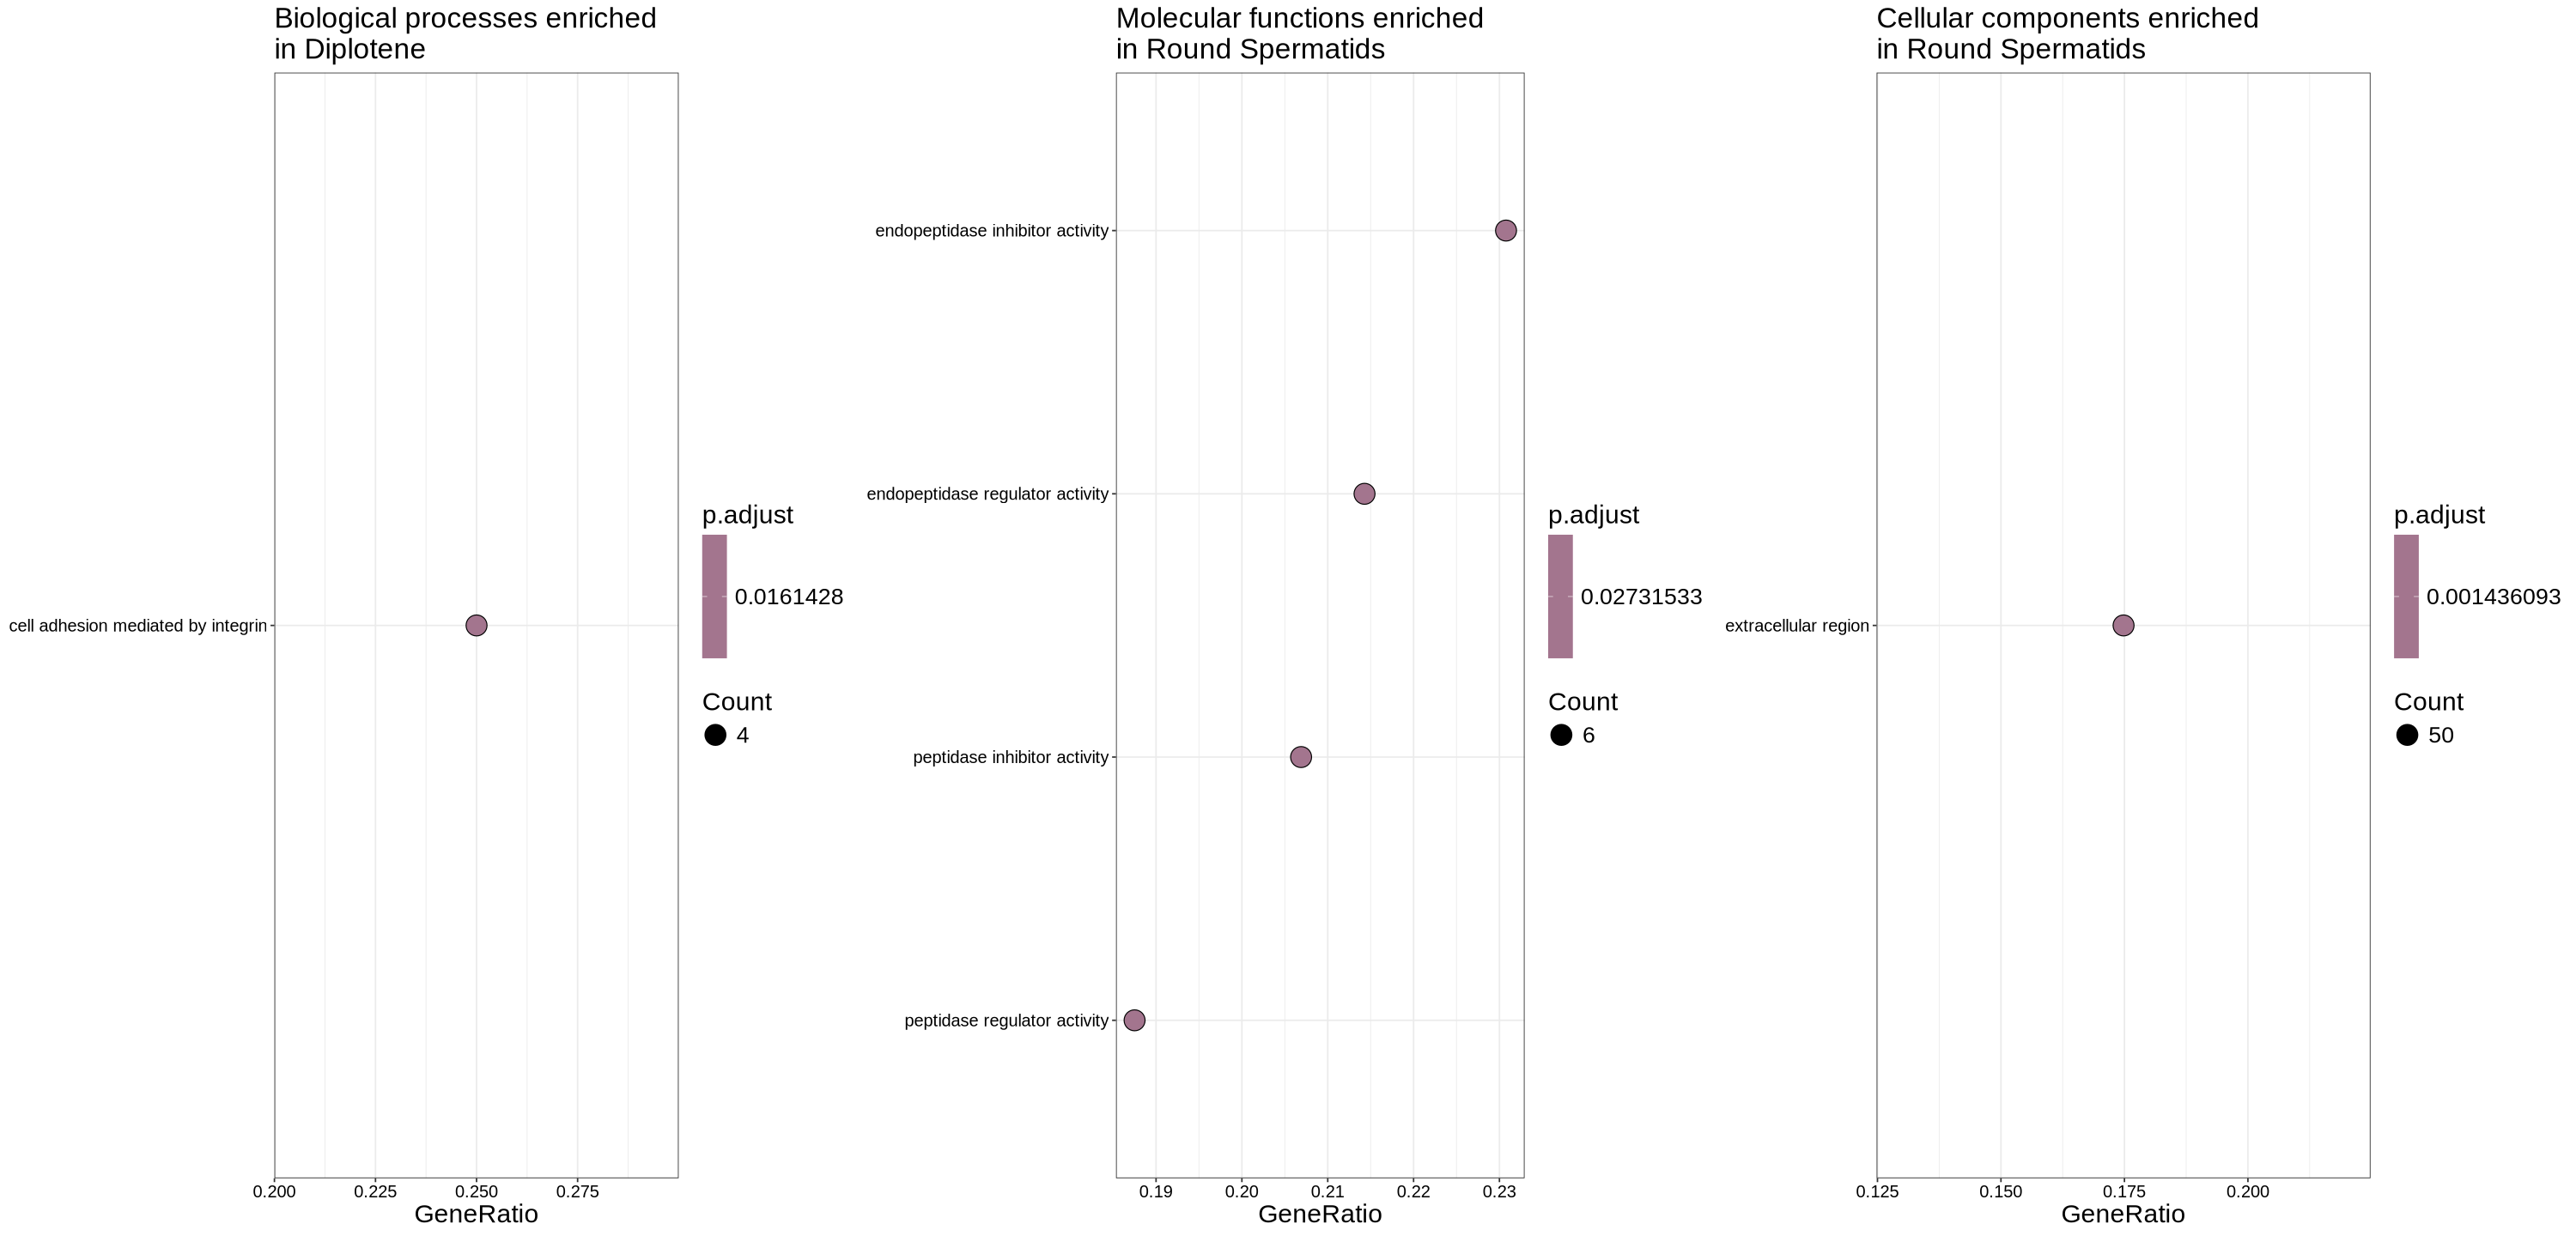

In [10]:
options(repr.plot.width=25, repr.plot.height=12)

plot1 = dotplot(objBP$Round.Spt, showCategory=20, label_format = 50) +
    ggtitle("Biological processes enriched\nin Diplotene") +
    theme(
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18),
        axis.text = element_text(size = 20),
        axis.title = element_text(size = 18),
        plot.title = element_text(size = 20)
    )

plot2 = dotplot(objMF$Diplotene, showCategory=20, label_format = 50) +
    ggtitle(paste("Molecular functions enriched\nin Round Spermatids")) +
    theme(
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18),
        axis.text = element_text(size = 18),
        axis.title = element_text(size = 18),
        plot.title = element_text(size = 20)
    )

plot3 = dotplot(objCC$Round.Spt, showCategory=20, label_format = 50) +
    ggtitle(paste("Cellular components enriched\nin Round Spermatids")) +
    theme(
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18),
        axis.text = element_text(size = 18),
        axis.title = element_text(size = 18),
        plot.title = element_text(size = 20)
    ) 

pdf(paste0(RES_FOLDER,"/GSEA_GO_",".pdf"), width=25, height=12)
    cowplot::plot_grid(plot1, plot2, plot3, ncol=3)
dev.off()

png(paste0(RES_FOLDER,"/GSEA_GO_",".png"), width = 2500, height = 1200, res = 100)
    cowplot::plot_grid(plot1, plot2, plot3, ncol=3)
dev.off()

cowplot::plot_grid(plot1, plot2, plot3, ncol=3)



In [11]:
dge

Nuclei_N,Nuclei_P,Nuclei_L,Cluster,ENTREZID
<chr>,<dbl>,<dbl>,<chr>,<chr>
CHPF,4.857361e-07,25.35345,Elong.Spt,743513
FATE1,6.251341e-06,25.08126,Elong.Spt,736536
BCAP31,9.482815e-06,24.99582,Elong.Spt,738935
LDHB,2.668654e-05,24.79099,Elong.Spt,465337
PRPS1,6.450290e-05,24.68714,Elong.Spt,465800
TCEAL9,1.066459e-04,24.67854,Elong.Spt,107971180
ACSL4,1.328241e-04,24.67772,Elong.Spt,740279
HMGCS2,2.423161e-04,24.62277,Elong.Spt,457169
TKTL1,6.726374e-05,24.60671,Elong.Spt,465937


In [12]:
conversion_table=data.frame(row.names = dge$Nuclei_N )
conversion_table['SYMBOL']=dge$Nuclei_N
conversion_table['ENTREZID']=dge$ENTREZID

In [14]:
names(objBP)

[1] "SpermatogoniaA" "SpermatogoniaB" "Leptotene"      "Zygotene"      
[5] "Pachytene"      "Diplotene"      "Round.Spt"      "Elong.Spt"

In [29]:
objBP[['Round.Spt']]

#
# Gene Set Enrichment Analysis
#
#...@organism 	 Pan troglodytes 
#...@setType 	 BP 
#...@keytype 	 ENTREZID 
#...@geneList 	 Named num [1:4991] 27 26 25.1 24.5 24.4 ...
 - attr(*, "names")= chr [1:4991] "465207" "736536" "465780" "450916" ...
#...nPerm 	 
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...1 enriched terms found
'data.frame':	1 obs. of  11 variables:
 $ ID             : chr "GO:0033627"
 $ Description    : chr "cell adhesion mediated by integrin"
 $ setSize        : int 16
 $ enrichmentScore: num -0.875
 $ NES            : num -2.22
 $ pvalue         : num 5.93e-06
 $ p.adjust       : num 0.0161
 $ qvalue         : num 0.0157
 $ rank           : num 55
 $ leading_edge   : chr "tags=25%, list=1%, signal=25%"
 $ core_enrichment: chr "748032/453537/454070/465721"
#...Citation
S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang, W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize multiomics data. Nature Protocols. 2024, 19(11):3292-3320 


In [30]:
for(N in names(objBP)){

    namesBP <- convert_core_enrichment(objBP[[N]]@result, conversion_table) 
    namesMF <- convert_core_enrichment(objMF[[N]]@result, conversion_table)
    namesCC <- convert_core_enrichment(objCC[[N]]@result, conversion_table)

    tableBP <-as.data.frame(objBP[[N]])
    tableBP['genesymbols'] = namesBP
    allBP[[N]] = tableBP

    tableMF <-as.data.frame(objMF[[N]])
    tableMF['genesymbols'] = namesMF
    allMF[[N]] = tableMF

    tableCC <-as.data.frame(objCC[[N]])
    tableCC['genesymbols'] = namesCC
    allCC[[N]] = tableCC
}



In [31]:
allBP

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [32]:
allMF

$SpermatogoniaA
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$SpermatogoniaB
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Leptotene
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Zygotene
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Pachytene
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Diplotene
                   ID                      Description setSize enrichmentScore
GO:0004866 GO:0004866 endopeptidase inhibitor activity      26       0.8419447
GO:0061135 GO:0061135 endopeptidase regulator activity      28       0.8258981
GO:0030414 GO:0030414     peptidase inhibitor activity      29       0.8157560
GO:0061134 GO:0061134     peptidase regulator activity      32       0.7966574
                NES       pvalue   p.adjust     qvalue rank
GO:0004866 1.927344 0.0001039007 0.02731533 0.02724846  120
GO:0061135 1.919196 0.0002117467 0.02731533 0.02724846  120
GO:0030414 1.906246 0.0001259263 0.02731533 0.02724846  120
GO:0061134 1.894649 0.0002036056 0.02731533 0.02724846  120
                            leading_edge
GO:0004866 tags=23%, list=2%, signal=23%
GO:0061135 tags=21%, list=2%, signal=21%
GO:0030414 tags=21%, list=2%, signal=20%
GO:0061134 tags=19%, list=2%, signal=18%
                                        core_enrichment
GO:0004866 468137/466899/744242/107971092/746406/460045
GO:0061135 468137/466899/744242/107971092/746406/460045
GO:0030414 468137/466899/744242/107971092/746406/460045
GO:0061134 468137/466899/744242/107971092/746406/460045
                                             genesymbols
GO:0004866 SERPINF1/SERPINH1/SERPINB9/TIMP1/CRIM1/COL6A3
GO:0061135 SERPINF1/SERPINH1/SERPINB9/TIMP1/CRIM1/COL6A3
GO:0030414 SERPINF1/SERPINH1/SERPINB9/TIMP1/CRIM1/COL6A3
GO:0061134 SERPINF1/SERPINH1/SERPINB9/TIMP1/CRIM1/COL6A3

$Round.Spt
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

$Elong.Spt
[1] ID              Description     setSize         enrichmentScore
[5] NES             pvalue          p.adjust        qvalue         
<0 rows> (or 0-length row.names)

In [34]:
allCC

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [36]:
allBP_table <- bind_rows(allBP, .id = "Cluster")
allMF_table <- bind_rows(allMF, .id = "Cluster")
allCC_table <- bind_rows(allCC, .id = "Cluster")
write.csv(allBP_table, file=paste0(RES_FOLDER, "/GSEA_GO_BP_all_clusters_LFC_comparison.csv"), row.names=FALSE)
write.csv(allMF_table, file=paste0(RES_FOLDER, "/GSEA_GO_MF_all_clusters_LFC_comparison.csv"), row.names=FALSE)
write.csv(allCC_table, file=paste0(RES_FOLDER, "/GSEA_GO_CC_all_clusters_LFC_comparison.csv"), row.names=FALSE)